In [33]:
import numpy as np
import pandas as pd
import plotly.express as px 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection  import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score , mean_squared_error

In [34]:
df = pd.read_csv('house_prices_practice.csv')

In [35]:
df.head(5)

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
0,1,7,1560,0,1658,1969,2,1,8059,177106
1,2,4,2827,2,1319,2012,3,4,13530,301044
2,3,8,3920,0,841,2010,1,4,9010,360609
3,4,5,3044,0,1058,1998,0,4,13207,240556
4,5,7,801,1,2428,2020,0,1,9117,193656


In [36]:
df['FullBath'].unique().sum()

np.int64(6)

In [37]:
df.isnull().sum()

Id              0
OverallQual     0
GrLivArea       0
GarageCars      0
TotalBsmtSF     0
YearBuilt       0
FullBath        0
BedroomAbvGr    0
LotArea         0
SalePrice       0
dtype: int64

In [38]:
df.drop(columns=['Id'] , axis=1 , inplace=True)

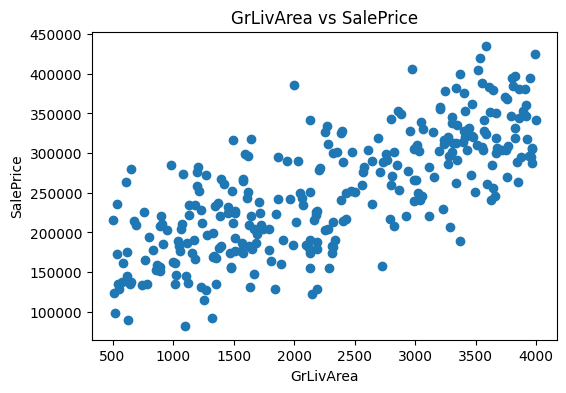

In [39]:
plt.figure(figsize=(6,4))
plt.scatter(df['GrLivArea'], df['SalePrice'])
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.title("GrLivArea vs SalePrice")
plt.show()


Text(0, 0.5, 'SalePrice')

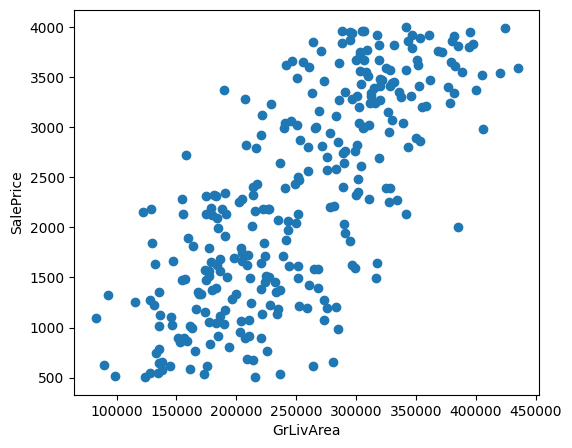

In [40]:
plt.figure(figsize=(6,5))
plt.scatter(df['SalePrice'],df['GrLivArea'])
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')

In [41]:
x = df.drop('SalePrice', axis=1)
y = df['SalePrice']

In [42]:
y

0      177106
1      301044
2      360609
3      240556
4      193656
        ...  
295    250604
296    329906
297    184623
298    303345
299    204982
Name: SalePrice, Length: 300, dtype: int64

In [43]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x , y ,test_size= 0.2,random_state=42 )

In [44]:
from sklearn.linear_model import LinearRegression

In [45]:
from sklearn.preprocessing import StandardScaler

In [46]:
scaler = StandardScaler()
scaler.fit(x_train)

x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)



In [47]:
from sklearn.linear_model import Ridge , Lasso

In [48]:
from sklearn.linear_model import RidgeCV

alphas = [0.01, 0.1, 1, 10, 100]

line_model = RidgeCV(alphas=alphas, scoring='neg_mean_squared_error')
line_model.fit(x_train, y_train)


y_pred = line_model.predict(x_test)


In [49]:
#line_model = LinearRegression() 
#line_model.fit(x_train,y_train)

In [50]:
y_pred = line_model.predict(x_test)
y_pred

array([239079.00509296, 190542.64650404, 397908.94662876, 223213.83139045,
       135290.15013744, 180371.11566051, 283768.1502367 , 204490.08711275,
       205810.81762759, 171557.11763861, 389553.09311219, 274147.87510846,
       116319.29194815, 171351.75806728, 293787.62131803, 314929.11286718,
       154968.22959388, 146163.48873017, 221276.56154277, 255188.01033256,
       235891.54219423, 167387.19647323, 209026.81307138, 289671.57731673,
       313256.30527428, 382462.22416663, 206561.48415992, 260802.56147959,
       285163.79246988, 443220.67522304, 402200.30276132, 292165.83757984,
       122232.22392575, 211115.20106467, 291039.00307071, 226697.21904449,
       342128.68562683, 243528.97126221, 235779.7761469 , 201537.90402091,
       237364.69782371, 334395.71951142, 313710.14099088, 292444.30070131,
       376774.28560317, 319322.87847172, 217387.52991778, 256841.3409875 ,
       218952.05250016, 332408.74916748, 305698.06657714, 321467.17936987,
       110520.62906244, 3

In [51]:
from sklearn.metrics import mean_squared_error, r2_score ,root_mean_squared_error
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)


RMSE: 12502.52064054541
R2 Score: 0.972449947616072


In [52]:
y_train_pred = line_model.predict(x_train)

from sklearn.metrics import r2_score
print("Train R2:", r2_score(y_train, y_train_pred))


Train R2: 0.9790344073199359


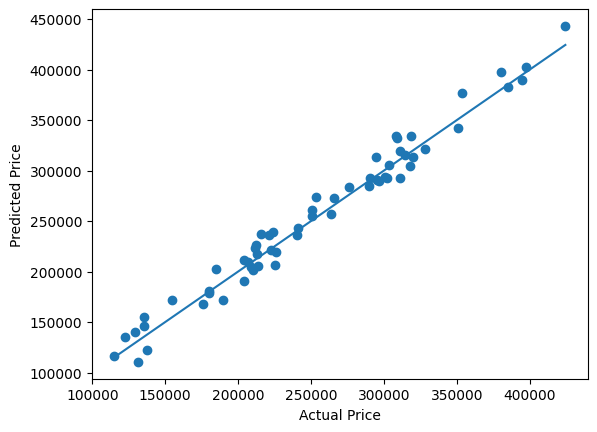

In [53]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])
plt.show()


In [54]:
import plotly.graph_objects as go

error = abs(y_test - y_pred)

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=y_test,
    y=y_pred,
    mode='markers',
    name='Predicted Prices',
    marker=dict(
        size=7,
        color=error,
        colorscale='Viridis',
        colorbar=dict(title='Absolute Error'),
        opacity=0.7
    )
))

fig.add_trace(go.Scatter(
    x=[y_test.min(), y_test.max()],
    y=[y_test.min(), y_test.max()],
    mode='lines',
    name='Perfect Prediction (y = x)',
    line=dict(
        width=3,
        dash='dash'
    )
))

fig.update_layout(
    title='Actual vs Predicted House Prices',
    xaxis_title='Actual Sale Price',
    yaxis_title='Predicted Sale Price',
    legend_title='Legend',
    template='plotly_white',
    width=800,
    height=650
)

fig.show()


In [55]:
import plotly.graph_objects as go

features = [
    'GarageCars',
    'OverallQual',
    'FullBath',
    'BedroomAbvGr',
    'YearBuilt',
    'GrLivArea',
    'TotalBsmtSF',
    'LotArea'
]

weights = [
    19109.641614,
    11914.688135,
    11040.343046,
    4812.061994,
    746.370978,
    55.410257,
    25.199018,
    -0.159522
]

fig = go.Figure()

fig.add_trace(go.Bar(
    x=weights,
    y=features,
    orientation='h',
    marker=dict(
        color=weights,
        colorscale='RdBu',
        colorbar=dict(title='Weight')
    ),
    name='Feature Weight'
))

fig.update_layout(
    title='Feature Importance (Linear Regression Weights)',
    xaxis_title='Weight',
    yaxis_title='Feature',
    template='plotly_white',
    width=900,
    height=500
)

fig.show()


In [56]:
x_test.head(5)

,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea
203,6,1456,2,2297,1958,3,2,2661
266,1,1796,1,2234,1998,2,1,10453
152,6,3856,3,1201,2022,1,4,8602
9,5,1492,1,2175,2011,1,2,11218
233,1,2149,0,394,1979,2,2,10555


In [57]:
y_pred = line_model.predict(x_test)
mes = mean_squared_error(y_test,y_pred)
rsq = root_mean_squared_error(y_test,y_pred)
rsq 

12502.52064054541

In [58]:
import joblib

joblib.dump(line_model, r"E:\AMIT\DEPI_AIS2_G3_ml\src\ML\Session_2\linear_model.pkl")


['E:\\AMIT\\DEPI_AIS2_G3_ml\\src\\ML\\Session_2\\linear_model.pkl']